In [1]:
import os
import random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2

from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix, f1_score

print("TensorFlow version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATA_ROOT = "/workspace/OCT2017"

TRAIN_DIR = os.path.join(DATA_ROOT, "train")
VAL_DIR   = os.path.join(DATA_ROOT, "val")
TEST_DIR  = os.path.join(DATA_ROOT, "test")

IMG_SIZE   = 224
BATCH_SIZE = 32
MAX_PER_CLASS = 8000


2025-12-02 14:12:37.537581: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764684757.552026   78743 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764684757.556762   78743 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1764684757.569586   78743 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1764684757.569597   78743 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1764684757.569599   78743 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
CLASS_NAMES = sorted(
    [d for d in os.listdir(TRAIN_DIR) if os.path.isdir(os.path.join(TRAIN_DIR, d))]
)

NUM_CLASSES = len(CLASS_NAMES)
print("Classes:", CLASS_NAMES)
print("Number of classes:", NUM_CLASSES)

train_filepaths = []
train_labels    = []

for class_idx, class_name in enumerate(CLASS_NAMES):
    class_dir = os.path.join(TRAIN_DIR, class_name)

    files = [
        os.path.join(class_dir, f)
        for f in os.listdir(class_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".tif", ".tiff"))
    ]

    print(f"{class_name}: found {len(files)} images")

    random.shuffle(files)
    files = files[:MAX_PER_CLASS]

    train_filepaths.extend(files)
    train_labels.extend([class_idx] * len(files))

train_filepaths = np.array(train_filepaths)
train_labels    = np.array(train_labels)

print("Balanced train images:", len(train_filepaths))


Classes: ['CNV', 'DME', 'DRUSEN', 'NORMAL']
Number of classes: 4
CNV: found 31427 images
DME: found 10939 images
DRUSEN: found 8017 images
NORMAL: found 26114 images
Balanced train images: 32000


In [3]:
def collect_filepaths_and_labels(base_dir, class_names):
    filepaths, labels = [], []
    for class_idx, class_name in enumerate(class_names):
        class_dir = os.path.join(base_dir, class_name)
        files = [
            os.path.join(class_dir, f)
            for f in os.listdir(class_dir)
            if f.lower().endswith((".jpg", ".jpeg", ".png", ".tif", ".tiff"))
        ]
        filepaths.extend(files)
        labels.extend([class_idx] * len(files))
        print(f"{base_dir} | {class_name}: {len(files)}")
    return np.array(filepaths), np.array(labels)

val_filepaths,  val_labels  = collect_filepaths_and_labels(VAL_DIR, CLASS_NAMES)
test_filepaths, test_labels = collect_filepaths_and_labels(TEST_DIR, CLASS_NAMES)

print("Val images:", len(val_filepaths))
print("Test images:", len(test_filepaths))


/workspace/OCT2017/val | CNV: 8
/workspace/OCT2017/val | DME: 8
/workspace/OCT2017/val | DRUSEN: 8
/workspace/OCT2017/val | NORMAL: 8
/workspace/OCT2017/test | CNV: 242
/workspace/OCT2017/test | DME: 242
/workspace/OCT2017/test | DRUSEN: 242
/workspace/OCT2017/test | NORMAL: 242
Val images: 32
Test images: 968


In [4]:
clahe = cv2.createCLAHE(clipLimit=1.5, tileGridSize=(4,4))

def apply_clahe_np(img):
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)

    cl = clahe.apply(l)  
    
    merged = cv2.merge((cl, a, b))
    rgb = cv2.cvtColor(merged, cv2.COLOR_LAB2RGB)

    # Just scale to [0,1], no Z-score
    rgb = rgb.astype(np.float32) / 255.0

    return rgb



def load_and_preprocess(path, label):

    def _load_py(path_str):
        img = cv2.imread(path_str.decode("utf-8"))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = apply_clahe_np(img)
        return img

    img = tf.numpy_function(_load_py, [path], tf.float32)
    img.set_shape((IMG_SIZE, IMG_SIZE, 3))

    return img, label


In [5]:
def make_dataset(filepaths, labels, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))
    if shuffle:
        ds = ds.shuffle(len(filepaths), seed=SEED)
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_filepaths, train_labels, shuffle=True)
val_ds   = make_dataset(val_filepaths,  val_labels)
test_ds  = make_dataset(test_filepaths, test_labels)

train_ds, val_ds, test_ds


I0000 00:00:1764684760.112550   78743 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 872 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-80GB, pci bus id: 0000:44:00.0, compute capability: 8.0


(<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>,
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>,
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>)

In [6]:
data_augmentation = tf.keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.05),
        layers.RandomZoom(0.05),
        layers.RandomContrast(0.03),
    ],
    name="data_augmentation",
)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0018697232..1.0203259].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.021376908..1.0108382].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0056530237..1.0117534].


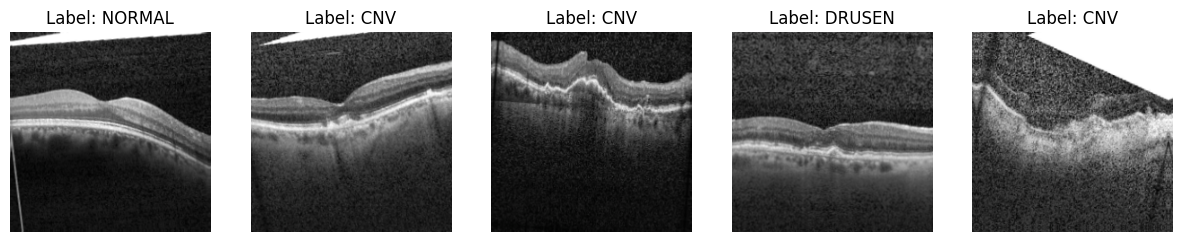

In [7]:
def show_augmented_images(dataset, n=5):
    for batch_images, batch_labels in dataset.take(1):
        images = batch_images[:n]
        labels = batch_labels[:n]
        break

    augmented = data_augmentation(images, training=True)

    plt.figure(figsize=(15, 4))
    for i in range(n):
        ax = plt.subplot(1, n, i + 1)
        plt.imshow(augmented[i].numpy())
        plt.title(f"Label: {CLASS_NAMES[labels[i].numpy()]}")
        plt.axis("off")
    plt.show()

show_augmented_images(train_ds, n=5)


In [ ]:
inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="input_image")

x = data_augmentation(inputs)

# ---- Convolution Blocks ----

# Block 1
x = layers.Conv2D(64, (3,3), padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)
x = layers.MaxPooling2D((2,2))(x)

# Block 2
x = layers.Conv2D(128, (3,3), padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)
x = layers.MaxPooling2D((2,2))(x)

# Block 3
x = layers.Conv2D(256, (3,3), padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)
x = layers.MaxPooling2D((2,2))(x)

# Block 4
x = layers.Conv2D(512, (3,3), padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)
x = layers.MaxPooling2D((2,2))(x)

# Block 5
x = layers.Conv2D(512, (3,3), padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)
x = layers.MaxPooling2D((2,2))(x)

# ---- Dense Head ----
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.6)(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

cnn_model = models.Model(inputs, outputs, name="Custom_CNN_OCT")

cnn_model.summary()


In [ ]:
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(3e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ModelCheckpoint("best_cnn_model_clahe_2.keras", monitor="val_loss", save_best_only=True),
]

history = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=35,
    callbacks=callbacks
)


In [ ]:
def plot_history(history):
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]

    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.plot(epochs, acc, label="Train Acc")
    plt.plot(epochs, val_acc, label="Val Acc")
    plt.title("Accuracy")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(epochs, loss, label="Train Loss")
    plt.plot(epochs, val_loss, label="Val Loss")
    plt.title("Loss")
    plt.legend()

    plt.show()

plot_history(history)


In [ ]:
test_results = cnn_model.evaluate(test_ds, verbose=1)
print("\nKeras test metrics:")
for name, value in zip(cnn_model.metrics_names, test_results):
    print(f"{name}: {value:.4f}")


In [ ]:
y_true = []
for _, labels in test_ds:
    y_true.extend(labels.numpy())
y_true = np.array(y_true)

y_prob = cnn_model.predict(test_ds, verbose=1)
y_pred = np.argmax(y_prob, axis=1)

print("\nClassification report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

macro_f1 = f1_score(y_true, y_pred, average="macro")
print(f"Macro F1-score: {macro_f1:.4f}")

cm = confusion_matrix(y_true, y_pred)
print("\nConfusion matrix:\n", cm)


In [ ]:
def plot_confusion_matrix(cm, class_names):
    fig, ax = plt.subplots(figsize=(6, 6))
    im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
    ax.figure.colorbar(im, ax=ax)

    ax.set(
        xticks=np.arange(len(class_names)),
        yticks=np.arange(len(class_names)),
        xticklabels=class_names,
        yticklabels=class_names
    )
    ax.set_ylabel("True label")
    ax.set_xlabel("Predicted label")
    ax.set_title("Confusion Matrix")

    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j, i, str(cm[i, j]),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black"
            )

    plt.tight_layout()
    plt.show()

plot_confusion_matrix(cm, CLASS_NAMES)
